Notice that in this version K_F is allowed to be build up before entry. The rtesults show that most firms only build up capital the period before they enter so it is not that important anyway. However, the firm needs a positive K_F for the cutoff to be well defined. 

In [227]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_X_HF = ("X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_X_HF

    def __post_init__(self) -> None:
        allowed = {"X", "HF"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")
        if len(self.active_modes) == 0:
            raise ValueError("Need at least one active regime.")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}


# ============================================================
# 2. PARAMETERS
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.98
    delta: float = 0.10

    # Adjustment costs
    phi_H: float = 1.5
    phi_F: float = 1.8

    # Terminal liquidation values
    xi_H: float = 0.40
    xi_F: float = 0.40

    # Marginal investment costs
    q_H: float = 1.0
    q_F: float = 1.0

    # CES / reduced-form parameters
    sigma: float = 5.0
    alpha: float = 0.30

    # Demand / cost shifters
    A_H: float = 1.0
    A_F: float = 1.0
    Lambda_H: float = 1.0
    Lambda_F: float = 1.0
    w_H: float = 1.0
    w_F: float = 1.0
    tau_X: float = 1.15

    # Fixed operating costs
    f_H_op: float = 0.03
    f_X_op: float = 0.015
    f_F_op: float = 0.035 # Notice

    # Sunk switching cost
    f_F_E: float = 0.10
    f_scope: float = 0.05

    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        val = 1.0 - self.a * self.gamma
        if val <= 0:
            raise ValueError("Need mu = 1 - a * gamma > 0.")
        return val

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        return self.alpha * self.rho


# ============================================================
# 3. PRODUCTIVITY PROCESSES
# ============================================================

def make_constant_productivity_transition(n_s: int) -> np.ndarray:
    """Deterministic productivity process: s_{t+1} = s_t."""
    return np.eye(n_s)


def fixed_s_process(s_value: float) -> Tuple[np.ndarray, np.ndarray]:
    """One-point productivity grid with constant s over time."""
    if s_value <= 0.0:
        raise ValueError("Need s_value > 0.")
    s_grid = np.array([float(s_value)])
    P = make_constant_productivity_transition(1)
    return s_grid, P


def rouwenhorst(
    n: int,
    rho: float,
    sigma_eps: float,
    mu: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho**2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


# ============================================================
# 4. TECHNOLOGY, PROFITS, COSTS
# ============================================================

def investment_cost(i: float, phi: float, q: float) -> float:
    return q * i + 0.5 * phi * i**2


def next_capital(K: float, i: float, delta: float) -> float:
    return (1.0 - delta) * K + i


def terminal_value(KH: float, KF: float, p: ModelParams) -> float:
    return p.xi_H * KH + p.xi_F * KF


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    if prev_mode == new_mode:
        return 0.0
    if prev_mode == "X" and new_mode == "HF":
        return p.f_F_E + p.f_scope
    return 0.0


def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def omega_H(p: ModelParams) -> float:
    Rbar_H = p.Lambda_H * ((p.a * p.gamma * p.Lambda_H) / p.w_H) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_H * (p.A_H ** p.rho)


def omega_F(p: ModelParams) -> float:
    Rbar_F = p.Lambda_F * ((p.a * p.gamma * p.Lambda_F) / p.w_F) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_F * (p.A_F ** p.rho)


def omega_X(p: ModelParams) -> float:
    chi_X = (p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma
    Xi_X = p.Lambda_H + p.Lambda_F * (chi_X ** p.a)
    w_X_eff = p.w_H * (1.0 + p.tau_X * chi_X) ** (1.0 / p.gamma)
    Rbar_X = Xi_X * ((p.a * p.gamma * Xi_X) / w_X_eff) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_X * (p.A_H ** p.rho)

def profit_D(KH: float, s: float, p: ModelParams) -> float:
    return omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op

def profit_X(KH: float, s: float, p: ModelParams) -> float:
    return omega_X(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op - p.f_X_op


def profit_HF(KH: float, KF: float, s: float, p: ModelParams) -> float:
    home = omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)
    foreign = omega_F(p) * _safe_power(KF, p.kappa, p.eps) * (s ** p.rho)
    return home + foreign - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, s: float, p: ModelParams) -> float:
    if mode == "X":
        return profit_X(KH, s, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, p)
    raise ValueError(f"Unknown mode: {mode}")


# ============================================================
# 5. INTERPOLATION / EXPECTATIONS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.argmin(np.abs(grid - x)))


def local_index_window(center: int, n: int, radius: int) -> np.ndarray:
    lo = max(center - radius, 0)
    hi = min(center + radius, n - 1)
    return np.arange(lo, hi + 1)


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(len(s_grid)):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                V[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])

    return value_obj


def build_expected_grid_from_markov(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    V_next shape:
        (n_prev_mode, n_KH, n_KF, n_s_next)

    Returns:
        EV shape = (n_prev_mode, n_KH, n_KF, n_s_current)
        with EV[..., s_cur] = beta * E[V_next | s_cur]
    """
    n_prev, n_KH, n_KF, _ = V_next.shape
    n_s_cur = P.shape[0]

    EV = np.empty((n_prev, n_KH, n_KF, n_s_cur))
    for pm in range(n_prev):
        for s_cur in range(n_s_cur):
            EV[pm, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :],
                P[s_cur, :],
                axes=([2], [0]),
            )
    return EV


def build_expected_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(EV.shape[3]):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                EV[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_expected_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])

    return EV_obj


# ============================================================
# 6. FAST TERMINAL-PERIOD SOLVER
# ============================================================
from dataclasses import replace

def terminal_investment_kkt(p: ModelParams) -> Tuple[float, float]:
    """
    Last decision period:
        q_H + phi_H * i_H = beta * xi_H
        q_F + phi_F * i_F = beta * xi_F
    with non-negativity constraints.

    Also handles the zero-friction case phi = 0.
    """
    # Home
    if p.phi_H > 0:
        iH = max((p.beta * p.xi_H - p.q_H) / p.phi_H, 0.0)
    else:
        if p.q_H >= p.beta * p.xi_H:
            iH = 0.0
        else:
            raise ValueError(
                "Terminal problem is unbounded for H when phi_H=0 and q_H < beta*xi_H."
            )

    # Foreign
    if p.phi_F > 0:
        iF = max((p.beta * p.xi_F - p.q_F) / p.phi_F, 0.0)
    else:
        if p.q_F >= p.beta * p.xi_F:
            iF = 0.0
        else:
            raise ValueError(
                "Terminal problem is unbounded for F when phi_F=0 and q_F < beta*xi_F."
            )

    return float(iH), float(iF)


def solve_terminal_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
) -> Dict[str, float]:
    iH, iF = terminal_investment_kkt(p)

    KH_next = next_capital(KH, iH, p.delta)
    KF_next = next_capital(KF, iF, p.delta)

    pi = flow_profit(mode, KH, KF, s, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
    cont = p.beta * terminal_value(KH_next, KF_next, p)

    return {
        "mode": mode,
        "value": pi - switch - adjust + cont,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH_next,
        "KF_next": KF_next,
        "continuation": cont,
    }


def solve_terminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    branches = {
                        mode: solve_terminal_branch(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=KH,
                            KF=KF,
                            s=s,
                            p=p,
                        )
                        for mode in cfg.active_modes
                    }
                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }


# ============================================================
# 7. FAST PRE-TERMINAL SOLVER
# ============================================================

def solve_branch_local_search(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s_idx: int,
    s_grid: np.ndarray,
    EV_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Fast local search over next-period capital grid points.

    The search starts around depreciated current capital and expands only if
    the optimum hits the edge of the local window.
    """
    s = float(s_grid[s_idx])

    center_H = nearest_index(KH_grid, (1.0 - p.delta) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta) * KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)
    visited = set()
    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)
        idx_F = local_index_window(center_F, n_F, radius)

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta) * KH
            if iH < -1e-12:
                continue

            for iF_idx in idx_F:
                KF_next = float(KF_grid[iF_idx])
                iF = KF_next - (1.0 - p.delta) * KF
                if iF < -1e-12:
                    continue

                pi = flow_profit(mode, KH, KF, s, p)
                switch = switching_cost(prev_mode, mode, p)
                adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
                EV = EV_obj(mode, KH_next, KF_next, s_idx)
                val = pi - switch - adjust + EV

                if val > best_val:
                    best_val = val
                    best_idx = (iH_idx, iF_idx)
                    best_local = {
                        "mode": mode,
                        "value": val,
                        "profit": pi,
                        "switch_cost": switch,
                        "iH": float(iH),
                        "iF": float(iF),
                        "KH_next": KH_next,
                        "KF_next": KF_next,
                        "EV": EV,
                    }

        if best_idx is None or best_local is None:
            raise RuntimeError("Local search failed to find a feasible candidate.")

        best = best_local
        iH_idx, iF_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))

        if hit_edge_H or hit_edge_F:
            center_H, center_F = iH_idx, iF_idx
            continue

        break

    if best is None:
        raise RuntimeError("Local search terminated without a solution.")

    return best


def solve_nonterminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    next_period_sol: Dict[str, object],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    EV_grid = build_expected_grid_from_markov(
        V_next=next_period_sol["V"],
        P=P,
        beta=p.beta,
    )
    EV_interps = build_expected_interpolators(KH_grid, KF_grid, EV_grid, cfg)
    EV_obj = make_expected_value_callable(KH_grid, KF_grid, EV_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for s_idx in range(n_s):
                    branches = {
                        mode: solve_branch_local_search(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=KH,
                            KF=KF,
                            s_idx=s_idx,
                            s_grid=s_grid,
                            EV_obj=EV_obj,
                            p=p,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            radius=radius,
                            max_expansions=max_expansions,
                        )
                        for mode in cfg.active_modes
                    }
                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, s_idx] = best["value"]
                    policy_mode[pm, i, j, s_idx] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, s_idx] = best["iH"]
                    iF_star[pm, i, j, s_idx] = best["iF"]
                    KH_next_star[pm, i, j, s_idx] = best["KH_next"]
                    KF_next_star[pm, i, j, s_idx] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
        "expected_grid": EV_grid,
        "expected_interpolators": EV_interps,
        "expected_callable": EV_obj,
    }


# ============================================================
# 8. GENERIC FINITE-HORIZON SOLVER
# ============================================================

def solve_finite_horizon_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Solve a finite-horizon model with n_periods decision periods.

    Timing:
        t = 0, ..., n_periods - 1     : regime and investment choice
        t = n_periods                 : liquidation value only

    The last decision period is solved with the closed-form KKT.
    All earlier periods use the fast expectation-based local search.
    """
    if n_periods < 1:
        raise ValueError("Need n_periods >= 1.")

    period_solutions: List[Optional[Dict[str, object]]] = [None] * n_periods

    period_solutions[-1] = solve_terminal_period_grid(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    for t in range(n_periods - 2, -1, -1):
        period_solutions[t] = solve_nonterminal_period_grid(
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            s_grid=s_grid,
            P=P,
            next_period_sol=period_solutions[t + 1],
            p=p,
            cfg=cfg,
            radius=radius,
            max_expansions=max_expansions,
        )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "s_grid": s_grid,
        "P": P,
        "n_periods": n_periods,
        "p": p,
        "cfg": cfg,
        "period_solutions": period_solutions,
        "solution_t0": period_solutions[0],
    }


# ============================================================
# 9. FIXED-s SOLVER
# ============================================================

def solve_fixed_s_finite_horizon(
    s_value: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    s_grid, P = fixed_s_process(s_value)

    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "fixed_s"
    bundle["s_value"] = float(s_value)
    return bundle


# ============================================================
# 10. STOCHASTIC-s SOLVER
# ============================================================

def solve_stochastic_s_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "stochastic_s"
    return bundle


def solve_rouwenhorst_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    n_s: int = 11,
    rho: float = 0.90,
    sigma_eps: float = 0.12,
    mu: float = 0.0,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    z_grid, s_grid, P = rouwenhorst(n=n_s, rho=rho, sigma_eps=sigma_eps, mu=mu)

    bundle = solve_stochastic_s_finite_horizon(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["z_grid"] = z_grid
    return bundle


# ============================================================
# 11. POLICY SIMULATION
# ============================================================

def simulate_one_path(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: Optional[int] = None,
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    P = model_bundle["P"]
    cfg = model_bundle["cfg"]
    n_periods = model_bundle["n_periods"]
    period_solutions = model_bundle["period_solutions"]

    rng = np.random.default_rng(seed)

    KH_path = [float(KH0)]
    KF_path = [float(KF0)]
    s_idx_path = [int(s0_idx)]
    s_path = [float(s_grid[s0_idx])]
    mode_path: List[str] = []
    iH_path: List[float] = []
    iF_path: List[float] = []

    prev_mode = initial_prev_mode

    for t in range(n_periods):
        sol_t = period_solutions[t]

        i = nearest_index(KH_grid, KH_path[-1])
        j = nearest_index(KF_grid, KF_path[-1])
        k = s_idx_path[-1]
        pm = cfg.mode_to_index[prev_mode]

        mode = cfg.index_to_mode[int(sol_t["policy_mode"][pm, i, j, k])]
        iH = float(sol_t["iH_star"][pm, i, j, k])
        iF = float(sol_t["iF_star"][pm, i, j, k])
        KH_next = float(sol_t["KH_next_star"][pm, i, j, k])
        KF_next = float(sol_t["KF_next_star"][pm, i, j, k])

        mode_path.append(mode)
        iH_path.append(iH)
        iF_path.append(iF)
        KH_path.append(KH_next)
        KF_path.append(KF_next)

        if t < n_periods - 1:
            if stochastic:
                k_next = int(rng.choice(np.arange(len(s_grid)), p=P[k, :]))
            else:
                k_next = k
            s_idx_path.append(k_next)
            s_path.append(float(s_grid[k_next]))

        prev_mode = mode

    return {
        "KH_path": KH_path,
        "KF_path": KF_path,
        "s_idx_path": s_idx_path,
        "s_path": s_path,
        "mode_path": mode_path,
        "iH_path": iH_path,
        "iF_path": iF_path,
    }


def simulate_many_paths(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    n_firms: int = 100,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: int = 123,
) -> List[Dict[str, object]]:
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=n_firms)

    return [
        simulate_one_path(
            model_bundle=model_bundle,
            KH0=KH0,
            KF0=KF0,
            s0_idx=s0_idx,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=int(seeds[i]),
        )
        for i in range(n_firms)
    ]


# ============================================================
# 12. SMALL PRINTER
# ============================================================

def print_path_summary(path: Dict[str, object], label: str = "path") -> None:
    print(f"\\n=== {label} ===")
    print("modes:   ", path["mode_path"])
    print("iH path: ", [round(x, 4) for x in path["iH_path"]])
    print("iF path: ", [round(x, 4) for x in path["iF_path"]])
    print("KH path: ", [round(x, 4) for x in path["KH_path"]])
    print("KF path: ", [round(x, 4) for x in path["KF_path"]])
    print("s path:  ", [round(x, 4) for x in path["s_path"]])

In [228]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.0, 40)
KF_grid = np.linspace(0.00, 2.0, 20)

# Fixed-s version
model_fixed = solve_fixed_s_finite_horizon(
    s_value=1.0,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    n_periods=13,
    p=p,
    cfg=cfg,
)

In [229]:
# Stochastic version
z_grid, s_grid, P = rouwenhorst(n=15, rho=0.90, sigma_eps=0.12)
model_stoch = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=13,
    p=p,
    cfg=cfg,
)

from dataclasses import replace


1. For 11 prod states

    a.  $50 \times 50$ states takes 32 minutes to solve 

    b. $40 \times 20$ takes 6 minutes

2. For 19 prod states. 

    b. $40 \times 20$ takes 12 minutes


In [230]:
# No-friction version
p_no_fric = replace(p, phi_H=0.0, phi_F=0.0)

model_stoch_no_fric = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=13,
    p=p_no_fric,
    cfg=cfg,
)

# Analysis 

### Step 1: Build inital exporter set

In [207]:
import numpy as np
import pandas as pd

def collect_initial_exporter_states(
    model_bundle: Dict[str, object],
    KF0_target: float = 0.0,
    initial_prev_mode: str = "X",
    kh_step: int = 1,
    s_idx_subset: Optional[list[int]] = None,
    require_static_export_premium: bool = True,
    export_premium_tol: float = 0.0,
) -> pd.DataFrame:
    """
    Collect initial states (s0, KH0, KF0) such that:
      - previous mode is X
      - KF0 is fixed near KF0_target
      - the optimal policy at t=0 is X in the reduced X/HF model
      - optionally: exporting weakly dominates domestic production on current flow profits

    Returns a DataFrame with one row per initial exporter state.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    sol_t0 = model_bundle["solution_t0"]

    pm = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]
    j0 = nearest_index(KF_grid, KF0_target)

    if s_idx_subset is None:
        s_idx_subset = list(range(len(s_grid)))

    rows = []
    for s_idx in s_idx_subset:
        for i in range(0, len(KH_grid), kh_step):
            chosen_mode_idx = int(sol_t0["policy_mode"][pm, i, j0, s_idx])
            if chosen_mode_idx != x_idx:
                continue

            KH0 = float(KH_grid[i])
            KF0 = float(KF_grid[j0])
            s0 = float(s_grid[s_idx])

            pi_X = flow_profit("X", KH0, KF0, s0, p)
            pi_D = profit_D(KH0, s0, p)
            export_premium = pi_X - pi_D

            if require_static_export_premium and export_premium < export_premium_tol:
                continue

            rows.append({
                "state_id": len(rows),
                "KH0": KH0,
                "KF0": KF0,
                "s0_idx": int(s_idx),
                "s0": s0,
                "initial_profit_X": pi_X,
                "initial_profit_D": pi_D,
                "export_premium": export_premium,
                "V0_X_region": float(sol_t0["V"][pm, i, j0, s_idx]),
            })

    df = pd.DataFrame(rows)
    return df.sort_values(["s0_idx", "KH0"]).reset_index(drop=True)


In [231]:
initial_exporters = collect_initial_exporter_states(
    model_bundle=model_stoch,
    KF0_target=0.0,
    initial_prev_mode="X",
    kh_step=1,        # increase to 2 or 3 if you want fewer initial states
    require_static_export_premium=True,
    export_premium_tol=0.01, # only keep states where exporting has at least a 0.01 profit premium over domestic 
)

print(initial_exporters.head())
print("Number of initial exporter states:", len(initial_exporters))

print("\n=== Initial exporter states with no frictions ===")

initial_exporters_NF = collect_initial_exporter_states(
    model_bundle=model_stoch_no_fric,
    KF0_target=0.0,
    initial_prev_mode="X",
    kh_step=1,        # increase to 2 or 3 if you want fewer initial states
    require_static_export_premium=True,
    export_premium_tol=0.01, # only keep states where exporting has at least a 0.01 profit premium over domestic 
)

print(initial_exporters.head())
print("Number of initial exporter states:", len(initial_exporters))

   state_id  KH0  KF0  s0_idx        s0  initial_profit_X  initial_profit_D  \
0         0  3.6  0.0       2  0.479138          0.091360          0.081025   
1         1  3.7  0.0       2  0.479138          0.093413          0.082697   
2         2  3.8  0.0       2  0.479138          0.095441          0.084348   
3         3  3.9  0.0       2  0.479138          0.097445          0.085980   
4         4  4.0  0.0       2  0.479138          0.099426          0.087593   

   export_premium  V0_X_region  
0        0.010335     1.602435  
1        0.010716     1.644663  
2        0.011093     1.616636  
3        0.011465     1.685666  
4        0.011833     1.783722  
Number of initial exporter states: 434

=== Initial exporter states with no frictions ===
   state_id  KH0  KF0  s0_idx        s0  initial_profit_X  initial_profit_D  \
0         0  3.6  0.0       2  0.479138          0.091360          0.081025   
1         1  3.7  0.0       2  0.479138          0.093413          0.082697   


### Step 2: Simulate many shock path from each inital state

In [209]:
def simulate_from_initial_exporter_grid(
    model_bundle: Dict[str, object],
    initial_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> list[dict]:
    """
    For each initial state in `initial_states`, simulate N firms forward.

    Returns a list of dictionaries, one per initial state:
        {
            "state_id": ...,
            "KH0": ...,
            "KF0": ...,
            "s0_idx": ...,
            "s0": ...,
            "paths": [path_1, ..., path_N]
        }
    """
    out = []

    for row_idx, row in initial_states.iterrows():
        state_seed = seed + 10000 * row_idx

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            s0_idx=int(row["s0_idx"]),
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=state_seed,
        )

        out.append({
            "state_id": int(row["state_id"]),
            "KH0": float(row["KH0"]),
            "KF0": float(row["KF0"]),
            "s0_idx": int(row["s0_idx"]),
            "s0": float(row["s0"]),
            "initial_profit_X": float(row["initial_profit_X"]),
            "paths": paths,
        })

    return out

In [232]:
sim_grid = simulate_from_initial_exporter_grid(
    model_bundle=model_stoch,
    initial_states=initial_exporters,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

print("Number of initial states simulated:", len(sim_grid))
print("Paths simulated from first state:", len(sim_grid[0]["paths"]))

# No frictions version
print("\n=== Simulating from initial exporter states with no frictions ===")

sim_grid_NF = simulate_from_initial_exporter_grid(
    model_bundle=model_stoch_no_fric,
    initial_states=initial_exporters_NF,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)
print("Number of initial states simulated (no frictions):", len(sim_grid_NF))
print("Paths simulated from first state (no frictions):", len(sim_grid_NF[0]["paths"]))

Number of initial states simulated: 434
Paths simulated from first state: 300

=== Simulating from initial exporter states with no frictions ===
Number of initial states simulated (no frictions): 434
Paths simulated from first state (no frictions): 300


### Step 3 
for each path, record: 
1. First period when HF is entered
2. Whether ever entered HF
3. Final regime
4. Paths of K_H and K_F

The first block has one row per simulated firm path. The second has one row per firm period

In [162]:
def _first_hf_entry_period(mode_path: list[str]) -> float:
    for t, m in enumerate(mode_path):
        if m == "HF":
            return float(t)
    return np.nan


def simulation_grid_to_summary_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    Convert the simulation output into one row per simulated firm-path.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            mode_path = path["mode_path"]
            first_hf = _first_hf_entry_period(mode_path)
            ever_hf = int(any(m == "HF" for m in mode_path))
            stay_x_all_periods = int(all(m == "X" for m in mode_path))
            final_mode = mode_path[-1]

            rows.append({
                "state_id": state["state_id"],
                "firm_id": firm_id,

                "KH0": state["KH0"],
                "KF0": state["KF0"],
                "s0_idx": state["s0_idx"],
                "s0": state["s0"],
                "initial_profit_X": state["initial_profit_X"],

                "ever_hf": ever_hf,
                "stay_x_all_periods": stay_x_all_periods,
                "first_hf_period": first_hf,
                "final_mode": final_mode,
                "final_is_hf": int(final_mode == "HF"),

                "KH_final": float(path["KH_path"][-1]),
                "KF_final": float(path["KF_path"][-1]),

                "total_iH": float(np.sum(path["iH_path"])),
                "total_iF": float(np.sum(path["iF_path"])),

                "mean_iH": float(np.mean(path["iH_path"])),
                "mean_iF": float(np.mean(path["iF_path"])),
            })

    return pd.DataFrame(rows)

In [163]:
def simulation_grid_to_long_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    Convert the simulation output into a long panel:
    one row per firm and period t.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            n_periods = len(path["mode_path"])

            for t in range(n_periods):
                rows.append({
                    "state_id": state["state_id"],
                    "firm_id": firm_id,
                    "t": t,

                    "KH0": state["KH0"],
                    "KF0": state["KF0"],
                    "s0_idx": state["s0_idx"],
                    "s0": state["s0"],
                    "initial_profit_X": state["initial_profit_X"],

                    "s_t": float(path["s_path"][t]),
                    "mode_t": path["mode_path"][t],
                    "is_hf_t": int(path["mode_path"][t] == "HF"),

                    "KH_t": float(path["KH_path"][t]),
                    "KF_t": float(path["KF_path"][t]),
                    "iH_t": float(path["iH_path"][t]),
                    "iF_t": float(path["iF_path"][t]),

                    "KH_tp1": float(path["KH_path"][t + 1]),
                    "KF_tp1": float(path["KF_path"][t + 1]),
                })

    return pd.DataFrame(rows)

In [233]:
summary_df = simulation_grid_to_summary_df(sim_grid)
long_df = simulation_grid_to_long_df(sim_grid)

print(summary_df.head())
print(long_df.head())

# No frictions version
print("\n=== Converting no-frictions simulation to DataFrames ===")
summary_df_NF = simulation_grid_to_summary_df(sim_grid_NF)
long_df_NF = simulation_grid_to_long_df(sim_grid_NF)

print(summary_df_NF.head())
print(long_df_NF.head())

   state_id  firm_id  KH0  KF0  s0_idx        s0  initial_profit_X  ever_hf  \
0         0        0  3.6  0.0       2  0.479138           0.09136        0   
1         0        1  3.6  0.0       2  0.479138           0.09136        0   
2         0        2  3.6  0.0       2  0.479138           0.09136        0   
3         0        3  3.6  0.0       2  0.479138           0.09136        0   
4         0        4  3.6  0.0       2  0.479138           0.09136        0   

   stay_x_all_periods  first_hf_period final_mode  final_is_hf  KH_final  \
0                   1              NaN          X            0      1.26   
1                   1              NaN          X            0      1.26   
2                   1              NaN          X            0      1.26   
3                   1              NaN          X            0      1.26   
4                   1              NaN          X            0      1.26   

   KF_final  total_iH  total_iF   mean_iH  mean_iF  
0       0.0    

### Step 4: Aggregate
For each $(s_0,K_0)$ compute 

1. HF-entry probability
2. median entry time 
3. probability of remaining in X 
4. average investment path



In [212]:
def aggregate_simulations_by_initial_state(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate simulated outcomes by initial state (state_id).
    """
    agg = (
        summary_df
        .groupby(["state_id", "s0_idx", "s0", "KH0", "KF0", "initial_profit_X"], as_index=False)
        .agg(
            n_paths=("firm_id", "count"),
            hf_share_ever=("ever_hf", "mean"),
            stay_x_share=("stay_x_all_periods", "mean"),
            final_hf_share=("final_is_hf", "mean"),
            mean_entry_period=("first_hf_period", "mean"),
            median_entry_period=("first_hf_period", "median"),
            mean_KH_final=("KH_final", "mean"),
            mean_KF_final=("KF_final", "mean"),
            mean_total_iH=("total_iH", "mean"),
            mean_total_iF=("total_iF", "mean"),
            mean_iH=("mean_iH", "mean"),
            mean_iF=("mean_iF", "mean"),
        )
    )

    return agg.sort_values(["s0_idx", "KH0"]).reset_index(drop=True)

def aggregate_by_initial_productivity(agg_state_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate state-level results further by initial productivity state.
    """
    out = (
        agg_state_df
        .groupby(["s0_idx", "s0"], as_index=False)
        .agg(
            n_initial_states=("state_id", "count"),
            avg_hf_share_ever=("hf_share_ever", "mean"),
            avg_stay_x_share=("stay_x_share", "mean"),
            avg_final_hf_share=("final_hf_share", "mean"),
            avg_entry_period=("mean_entry_period", "mean"),
        )
    )
    return out.sort_values("s0_idx").reset_index(drop=True)

In [234]:
agg_state_df = aggregate_simulations_by_initial_state(summary_df)
agg_s_df = aggregate_by_initial_productivity(agg_state_df)

print(agg_state_df.head(10))
print(agg_s_df)

# No frictions version
print("\n=== Aggregating no-frictions simulation results ===")
agg_state_df_NF = aggregate_simulations_by_initial_state(summary_df_NF)
agg_s_df_NF = aggregate_by_initial_productivity(agg_state_df_NF)

print(agg_state_df_NF.head(10))
print(agg_s_df_NF)

   state_id  s0_idx        s0  KH0  KF0  initial_profit_X  n_paths  \
0         0       2  0.479138  3.6  0.0          0.091360      300   
1         1       2  0.479138  3.7  0.0          0.093413      300   
2         2       2  0.479138  3.8  0.0          0.095441      300   
3         3       2  0.479138  3.9  0.0          0.097445      300   
4         4       2  0.479138  4.0  0.0          0.099426      300   
5         5       3  0.555096  2.2  0.0          0.091214      300   
6         6       3  0.555096  2.3  0.0          0.094557      300   
7         7       3  0.555096  2.4  0.0          0.097835      300   
8         8       3  0.555096  2.5  0.0          0.101051      300   
9         9       3  0.555096  2.6  0.0          0.104209      300   

   hf_share_ever  stay_x_share  final_hf_share  mean_entry_period  \
0       0.000000      1.000000        0.000000                NaN   
1       0.000000      1.000000        0.000000                NaN   
2       0.000000      

# Figures
the figures displays
1. Heatmap of probabiliyt of becomming a HF at terminal time point 
2. Heatmap of mean period of entering HF
3. Comparison with no investment frictions

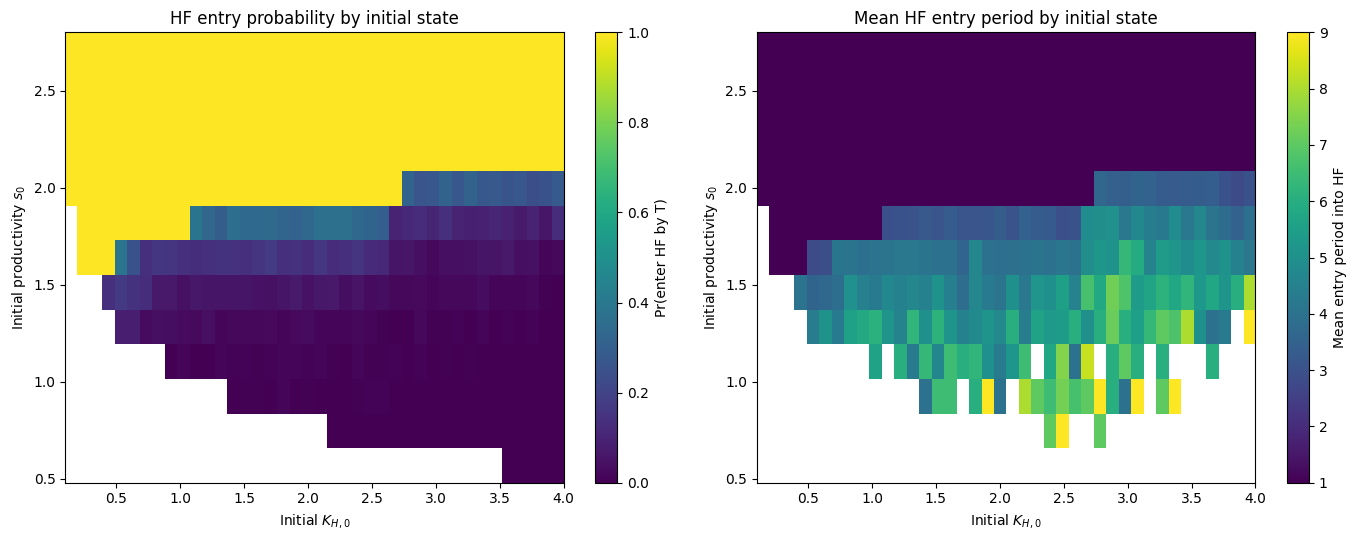

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def make_heatmap_matrix(df: pd.DataFrame, value_col: str):
    """
    Build a matrix with:
      rows    = s0
      columns = KH0
      entries = value_col
    """
    pivot = df.pivot(index="s0", columns="KH0", values=value_col)
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    y_vals = pivot.index.to_numpy(dtype=float)
    x_vals = pivot.columns.to_numpy(dtype=float)
    Z = pivot.to_numpy(dtype=float)

    return x_vals, y_vals, Z


# -----------------------------
# Build baseline matrices
# -----------------------------
x_vals_prob, y_vals_prob, Z_prob = make_heatmap_matrix(agg_state_df, "hf_share_ever")
x_vals_time, y_vals_time, Z_time = make_heatmap_matrix(agg_state_df, "mean_entry_period")

if not (np.allclose(x_vals_prob, x_vals_time) and np.allclose(y_vals_prob, y_vals_time)):
    raise ValueError("Baseline probability and timing matrices are not aligned.")




# Mask invalid cells for entry-time plots
Z_time_masked = np.ma.masked_invalid(Z_time)

# =============================
# FIGURE 1: Baseline 1x2
# =============================
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: baseline HF entry probability
im1 = axes1[0].imshow(
    Z_prob,
    origin="lower",
    aspect="auto",
    extent=[x_vals_prob.min(), x_vals_prob.max(), y_vals_prob.min(), y_vals_prob.max()]
)
axes1[0].set_xlabel(r"Initial $K_{H,0}$")
axes1[0].set_ylabel(r"Initial productivity $s_0$")
axes1[0].set_title("HF entry probability by initial state")
fig1.colorbar(im1, ax=axes1[0], label="Pr(enter HF by T)")

# Right: baseline mean HF entry period
im2 = axes1[1].imshow(
    Z_time_masked,
    origin="lower",
    aspect="auto",
    extent=[x_vals_time.min(), x_vals_time.max(), y_vals_time.min(), y_vals_time.max()]
)
axes1[1].set_xlabel(r"Initial $K_{H,0}$")
axes1[1].set_ylabel(r"Initial productivity $s_0$")
axes1[1].set_title("Mean HF entry period by initial state")
fig1.colorbar(im2, ax=axes1[1], label="Mean entry period into HF")

plt.tight_layout()
plt.show()




## Comparison Frictions vs No frictions
1. HF entry probability by state 
2. Distribution of entry periods among entrants
3. Cumulative entry probability 
4. Hazard rate 

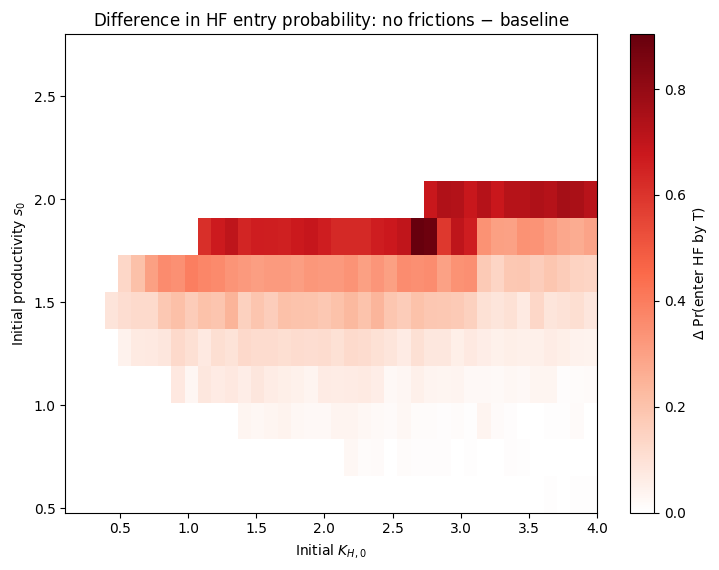

In [236]:
# -----------------------------
# Build no-frictions matrices
# -----------------------------
x_vals_prob_NF, y_vals_prob_NF, Z_prob_NF = make_heatmap_matrix(agg_state_df_NF, "hf_share_ever")
x_vals_time_NF, y_vals_time_NF, Z_time_NF = make_heatmap_matrix(agg_state_df_NF, "mean_entry_period")

if not (np.allclose(x_vals_prob_NF, x_vals_time_NF) and np.allclose(y_vals_prob_NF, y_vals_time_NF)):
    raise ValueError("No-frictions probability and timing matrices are not aligned.")

# -----------------------------
# Check that baseline and no-frictions grids match
# -----------------------------
if not (np.allclose(x_vals_prob, x_vals_prob_NF) and np.allclose(y_vals_prob, y_vals_prob_NF)):
    raise ValueError("Baseline and no-frictions grids do not match.")

Z_time_masked_NF = np.ma.masked_invalid(Z_time_NF)

# =============================
# FIGURE 2: Difference in HF entry probability
#   no frictions - baseline
# =============================
Z_diff = Z_prob_NF - Z_prob

# White at zero, darker red for larger positive differences
reds_from_white = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["white", "#fcbba1", "#fb6a4a", "#cb181d", "#67000d"]
)

fig2, ax2 = plt.subplots(1, 1, figsize=(7.5, 5.8))

im_diff = ax2.imshow(
    Z_diff,
    origin="lower",
    aspect="auto",
    extent=[x_vals_prob.min(), x_vals_prob.max(), y_vals_prob.min(), y_vals_prob.max()],
    cmap=reds_from_white,
    vmin=0.0,
    vmax=np.nanmax(Z_diff)
)

ax2.set_xlabel(r"Initial $K_{H,0}$")
ax2.set_ylabel(r"Initial productivity $s_0$")
ax2.set_title(r"Difference in HF entry probability: no frictions $-$ baseline")

fig2.colorbar(im_diff, ax=ax2, label=r"$\Delta$ Pr(enter HF by T)")

plt.tight_layout()
plt.show()

In [237]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_s0_idx_not_all_one(
    agg_state_df: pd.DataFrame,
    value_col: str = "hf_share_ever",
    tol: float = 1e-12,
) -> list[int]:
    """
    Return s0_idx values for which value_col is NOT equal to 1
    for all KH values in the support.
    """
    keep_s_idx = (
        agg_state_df.groupby("s0_idx")[value_col]
        .apply(lambda x: not np.all(np.isclose(x.to_numpy(dtype=float), 1.0, atol=tol)))
    )
    return keep_s_idx[keep_s_idx].index.tolist()


def build_entry_period_comparison_df(
    summary_df_fric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
) -> pd.DataFrame:
    """
    Keep only firms that ever enter HF and stack the two environments.
    """
    df_fric = summary_df_fric.loc[summary_df_fric["ever_hf"] == 1, ["first_hf_period"]].copy()
    df_fric["regime_case"] = label_fric

    df_nofric = summary_df_nofric.loc[summary_df_nofric["ever_hf"] == 1, ["first_hf_period"]].copy()
    df_nofric["regime_case"] = label_nofric

    out = pd.concat([df_fric, df_nofric], axis=0, ignore_index=True)
    out["first_hf_period"] = out["first_hf_period"].astype(int)
    return out


def plot_side_by_side_entry_hist(
    entry_df: pd.DataFrame,
    ax,
    title: str,
    decimals: int = 2,
):
    """
    Side-by-side bars for two groups in regime_case.
    """
    counts = (
        entry_df
        .groupby(["regime_case", "first_hf_period"], as_index=False)
        .size()
        .rename(columns={"size": "n"})
    )
    counts["share"] = counts.groupby("regime_case")["n"].transform(lambda x: x / x.sum())

    pivot = (
        counts.pivot(index="first_hf_period", columns="regime_case", values="share")
        .fillna(0.0)
        .sort_index()
    )

    periods = pivot.index.to_numpy(dtype=int)
    cases = list(pivot.columns)

    if len(cases) != 2:
        raise ValueError("Expected exactly two groups in regime_case.")

    x = np.arange(len(periods))
    width = 0.38

    bars1 = ax.bar(x - width / 2, pivot[cases[0]].to_numpy(), width=width, label=cases[0])
    bars2 = ax.bar(x + width / 2, pivot[cases[1]].to_numpy(), width=width, label=cases[1])

    for bars in [bars1, bars2]:
        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    h,
                    f"{h:.{decimals}f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(periods)
    ax.set_xlabel("First period of HF entry")
    ax.set_ylabel("Share of entrants")
    ax.set_title(title)
    ax.grid(alpha=0.2, axis="y")


def plot_entry_period_distribution_full_and_restricted(
    summary_df: pd.DataFrame,
    summary_df_NF: pd.DataFrame,
    agg_state_df: pd.DataFrame,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
):
    """
    1x2 figure:
      left  = full sample of entrants
      right = only entrants from s0 rows where hf_share_ever is not 1 for all KH
    """
    # Full sample
    entry_compare_full = build_entry_period_comparison_df(
        summary_df_fric=summary_df,
        summary_df_nofric=summary_df_NF,
        label_fric=label_fric,
        label_nofric=label_nofric,
    )

    # Restricted sample: choose s0 rows from baseline agg_state_df
    keep_s_idx = get_s0_idx_not_all_one(agg_state_df, value_col="hf_share_ever")

    summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
    summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

    entry_compare_restricted = build_entry_period_comparison_df(
        summary_df_fric=summary_df_r,
        summary_df_nofric=summary_df_NF_r,
        label_fric=label_fric,
        label_nofric=label_nofric,
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), sharey=True)

    plot_side_by_side_entry_hist(
        entry_compare_full,
        ax=axes[0],
        title="All entrants",
    )

    plot_side_by_side_entry_hist(
        entry_compare_restricted,
        ax=axes[1],
        title=r"Restricted: exclude $s_0$ rows with $\Pr(HF)=1$ for all $K_H$",
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)
    fig.suptitle("Distribution of HF entry periods among entrants", y=1.02)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    return keep_s_idx, entry_compare_full, entry_compare_restricted

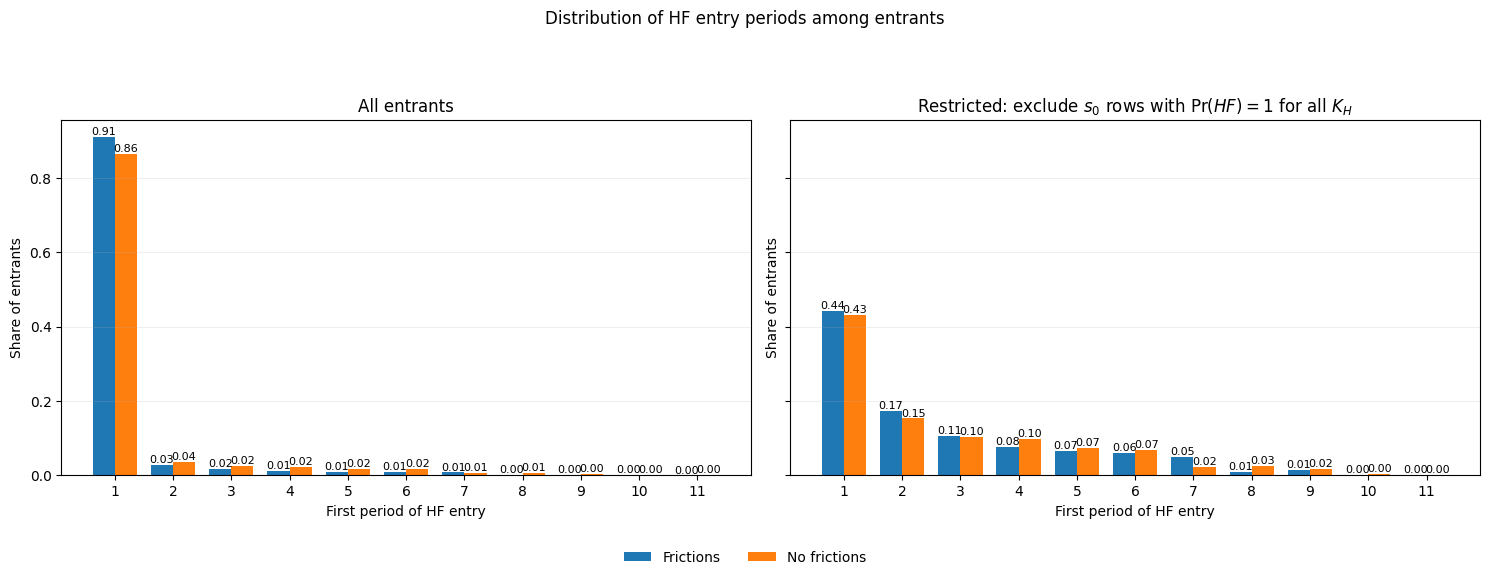

In [226]:
keep_s_idx, entry_compare_full, entry_compare_restricted = plot_entry_period_distribution_full_and_restricted(
    summary_df=summary_df,
    summary_df_NF=summary_df_NF,
    agg_state_df=agg_state_df,
    label_fric="Frictions",
    label_nofric="No frictions",
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_cumulative_hf_entry_df(
    summary_df: pd.DataFrame,
    n_periods: int,
    label: str,
) -> pd.DataFrame:
    """
    Build cumulative HF-entry shares by period.

    Output columns:
        period, cum_hf_share, case
    """
    first_hf = summary_df["first_hf_period"].to_numpy(dtype=float)
    ever_hf = ~np.isnan(first_hf)

    rows = []
    for t in range(n_periods):
        cum_share = np.mean(ever_hf & (first_hf <= t))
        rows.append({
            "period": t,
            "cum_hf_share": float(cum_share),
            "case": label,
        })

    return pd.DataFrame(rows)


def plot_cumulative_hf_entry_comparison(
    summary_df_fric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    n_periods: int,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
    title: str = "Cumulative share of firms that have entered HF",
) -> pd.DataFrame:
    """
    Plot cumulative HF-entry shares for frictions vs no frictions.
    """
    df_fric = build_cumulative_hf_entry_df(summary_df_fric, n_periods, label_fric)
    df_nofric = build_cumulative_hf_entry_df(summary_df_nofric, n_periods, label_nofric)

    plot_df = pd.concat([df_fric, df_nofric], axis=0, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    for label, sub in plot_df.groupby("case"):
        sub = sub.sort_values("period")
        ax.plot(
            sub["period"],
            sub["cum_hf_share"],
            marker="o",
            linewidth=2,
            label=label,
        )

    ax.set_xlabel("Period")
    ax.set_ylabel("Cumulative share entered HF")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    return plot_df

def get_s0_idx_not_all_one(
    agg_state_df: pd.DataFrame,
    value_col: str = "hf_share_ever",
    tol: float = 1e-12,
) -> list[int]:
    keep_s_idx = (
        agg_state_df.groupby("s0_idx")[value_col]
        .apply(lambda x: not np.all(np.isclose(x.to_numpy(dtype=float), 1.0, atol=tol)))
    )
    return keep_s_idx[keep_s_idx].index.tolist()



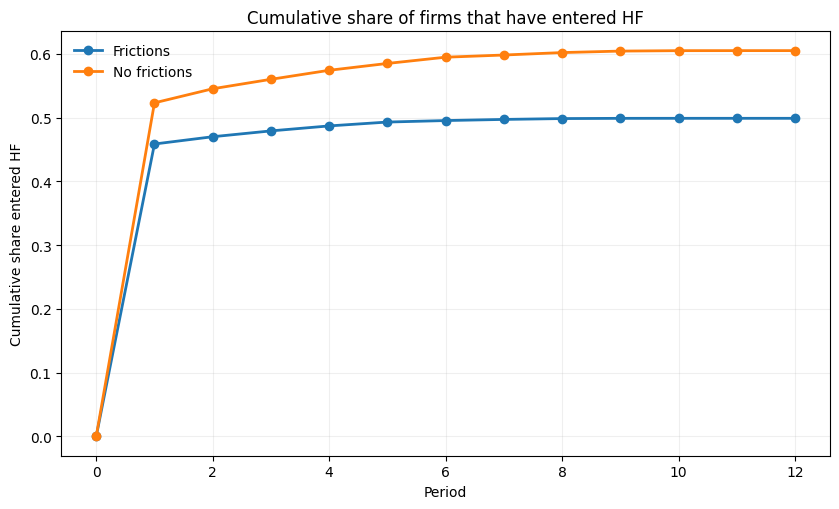

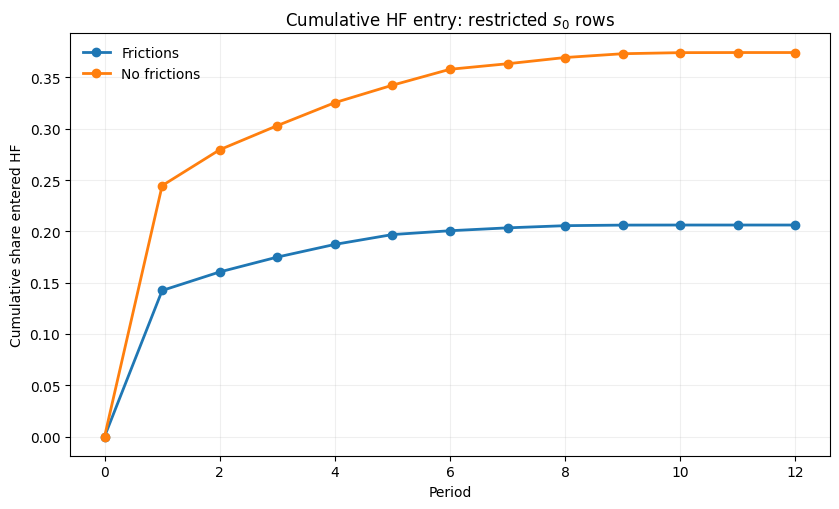

In [241]:
cum_entry_df = plot_cumulative_hf_entry_comparison(
    summary_df_fric=summary_df,
    summary_df_nofric=summary_df_NF,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
)

# only keep s0 rows where hf_share_ever is not 1 for all KH
keep_s_idx = get_s0_idx_not_all_one(agg_state_df, value_col="hf_share_ever")

summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

cum_entry_df_r = plot_cumulative_hf_entry_comparison(
    summary_df_fric=summary_df_r,
    summary_df_nofric=summary_df_NF_r,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
    title=r"Cumulative HF entry: restricted $s_0$ rows",
)


In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_hf_hazard_df(
    summary_df: pd.DataFrame,
    n_periods: int,
    label: str,
) -> pd.DataFrame:
    """
    Discrete-time hazard of first HF entry.

    h(t) = Pr(T = t | T >= t)

    where T is the first period of HF entry.
    """
    first_hf = summary_df["first_hf_period"].to_numpy(dtype=float)

    rows = []
    for t in range(n_periods):
        at_risk = np.sum(np.isnan(first_hf) | (first_hf >= t))
        enter_now = np.sum(first_hf == t)

        hazard = np.nan if at_risk == 0 else enter_now / at_risk

        rows.append({
            "period": t,
            "at_risk": int(at_risk),
            "enter_now": int(enter_now),
            "hazard": float(hazard) if at_risk > 0 else np.nan,
            "case": label,
        })

    return pd.DataFrame(rows)


def plot_hf_hazard_comparison(
    summary_df_fric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    n_periods: int,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
    title: str = "Hazard of first HF entry",
    annotate: bool = True,
) -> pd.DataFrame:
    """
    Plot hazard rates for frictions vs no frictions.
    """
    df_fric = build_hf_hazard_df(summary_df_fric, n_periods, label_fric)
    df_nofric = build_hf_hazard_df(summary_df_nofric, n_periods, label_nofric)
    hazard_df = pd.concat([df_fric, df_nofric], axis=0, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    for label, sub in hazard_df.groupby("case"):
        sub = sub.sort_values("period")
        ax.plot(
            sub["period"],
            sub["hazard"],
            marker="o",
            linewidth=2,
            label=label,
        )

        if annotate:
            for _, row in sub.iterrows():
                h = row["hazard"]
                if pd.notna(h) and h > 0:
                    ax.text(
                        row["period"],
                        h,
                        f"{h:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

    ax.set_xlabel("Period")
    ax.set_ylabel("Hazard of HF entry")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return hazard_df

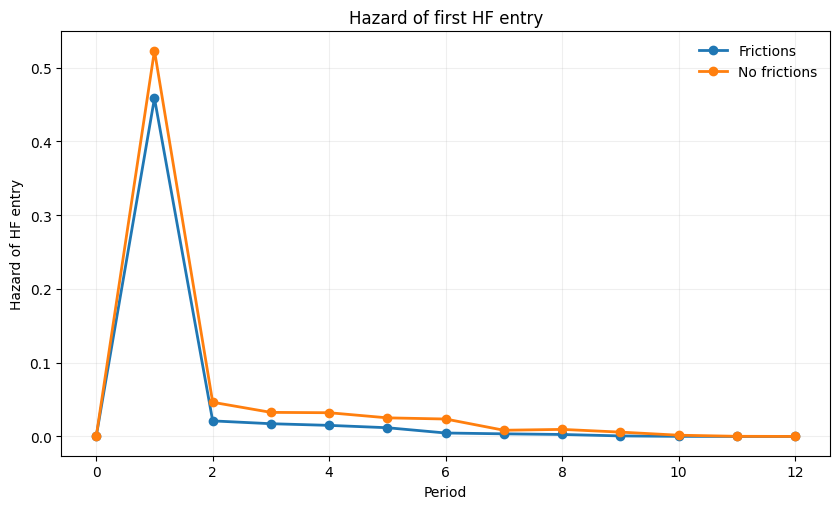

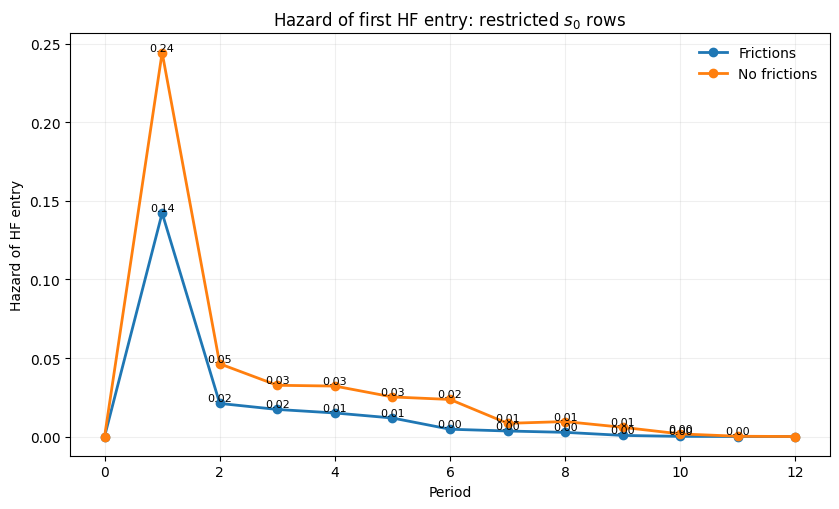

In [246]:
hazard_df = plot_hf_hazard_comparison(
    summary_df_fric=summary_df,
    summary_df_nofric=summary_df_NF,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
    annotate=False
)

def get_s0_idx_not_all_one(
    agg_state_df: pd.DataFrame,
    value_col: str = "hf_share_ever",
    tol: float = 1e-12,
) -> list[int]:
    keep_s_idx = (
        agg_state_df.groupby("s0_idx")[value_col]
        .apply(lambda x: not np.all(np.isclose(x.to_numpy(dtype=float), 1.0, atol=tol)))
    )
    return keep_s_idx[keep_s_idx].index.tolist()

keep_s_idx = get_s0_idx_not_all_one(agg_state_df)

summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

hazard_df_r = plot_hf_hazard_comparison(
    summary_df_fric=summary_df_r,
    summary_df_nofric=summary_df_NF_r,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
    title=r"Hazard of first HF entry: restricted $s_0$ rows",
)

###  Pick 3 inital states
1. Low probability of entering HF
2. 50% probability of enter HF
3. High probability of entering HF 

In [247]:
import numpy as np
import pandas as pd

def pick_representative_states(
    agg_state_df: pd.DataFrame,
    targets=(0.10, 0.50, 1.00),
    labels=("low", "middle", "high"),
) -> pd.DataFrame:
    """
    Pick three representative initial states:
      - one close to low HF-entry probability
      - one close to 50%
      - one close to high HF-entry probability

    Uses hf_share_ever from agg_state_df.
    """
    if len(targets) != len(labels):
        raise ValueError("targets and labels must have the same length.")

    df = agg_state_df.copy()
    chosen_rows = []
    used_state_ids = set()

    for target, label in zip(targets, labels):
        cand = df.loc[~df["state_id"].isin(used_state_ids)].copy()
        cand["distance_to_target"] = (cand["hf_share_ever"] - target).abs()

        # tie-break toward cleaner states
        cand = cand.sort_values(
            ["distance_to_target", "s0", "KH0"],
            ascending=[True, True, True]
        )

        row = cand.iloc[0].copy()
        row["target_prob"] = target
        row["label"] = label

        chosen_rows.append(row)
        used_state_ids.add(int(row["state_id"]))

    out = pd.DataFrame(chosen_rows).reset_index(drop=True)
    return out[
        [
            "label",
            "target_prob",
            "state_id",
            "s0",
            "KH0",
            "KF0",
            "hf_share_ever",
            "mean_entry_period",
            "stay_x_share",
            "initial_profit_X",
        ]
    ]


selected_states = pick_representative_states(agg_state_df)
print(selected_states)

    label  target_prob  state_id        s0  KH0  KF0  hf_share_ever  \
0     low          0.1     223.0  1.342196  3.0  0.0       0.103333   
1  middle          0.5     204.0  1.342196  1.1  0.0       0.386667   
2    high          1.0     156.0  1.158532  0.2  0.0       1.000000   

   mean_entry_period  stay_x_share  initial_profit_X  
0           4.193548      0.896667          0.758287  
1           2.965517      0.613333          0.419730  
2           1.003333      0.000000          0.095336  


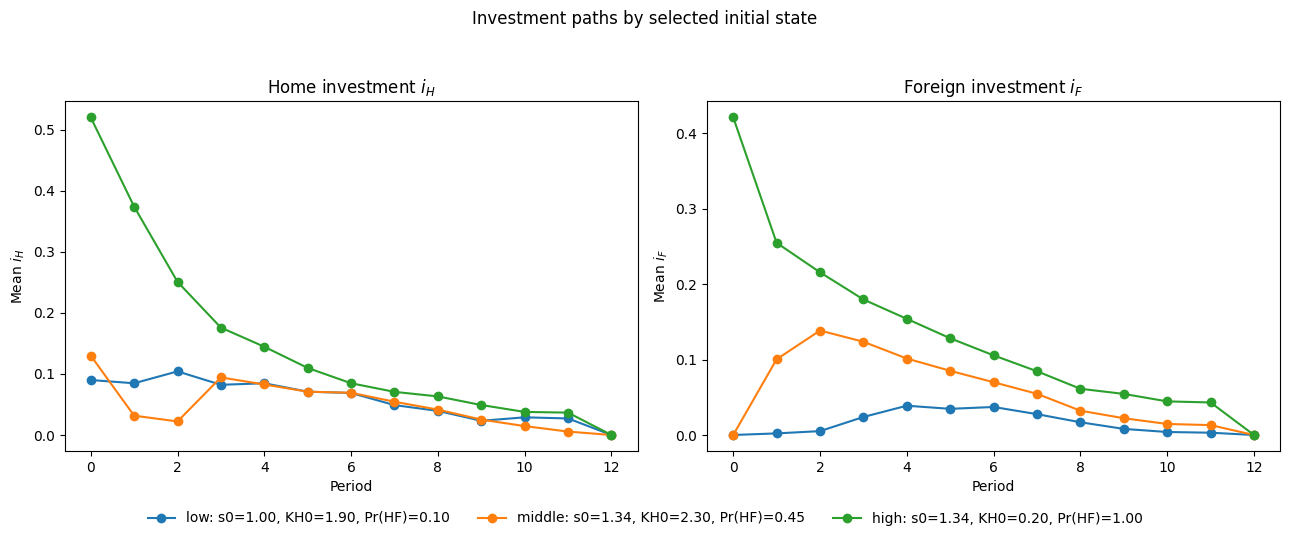

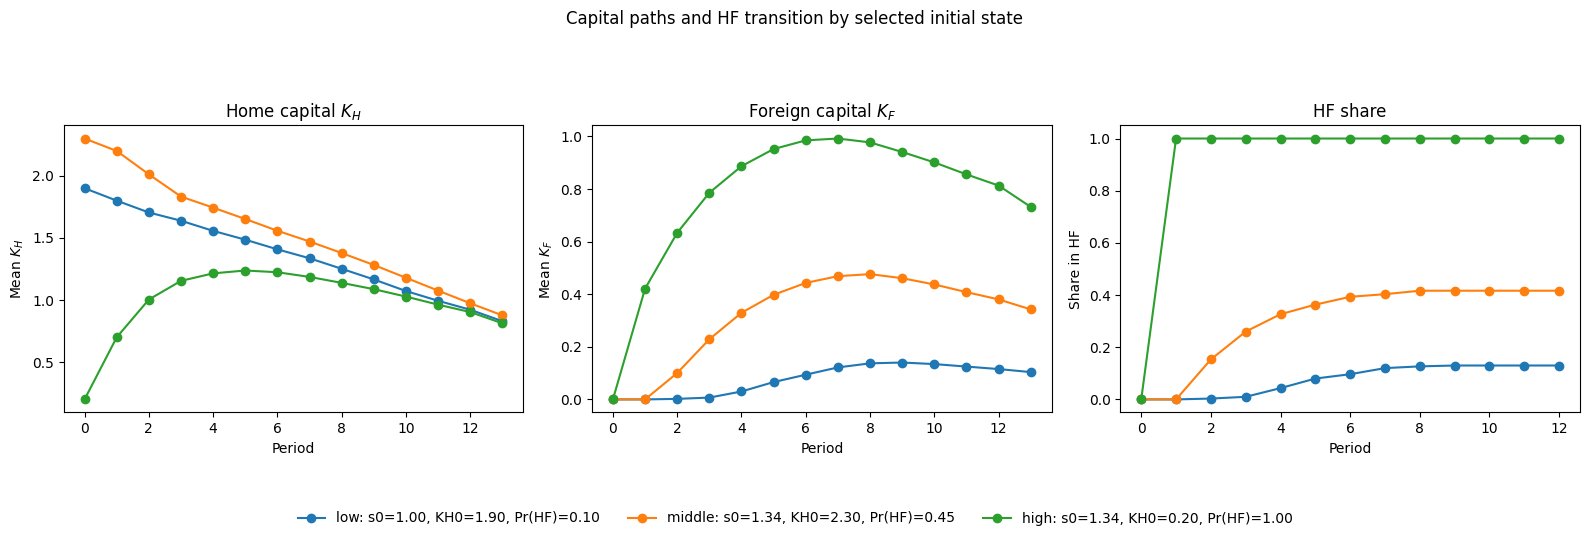

In [205]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_selected_states(
    model_bundle: Dict[str, object],
    selected_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> dict:
    """
    Simulate N firms from each selected initial state.
    Returns a dict keyed by label.
    """
    out = {}

    for idx, row in selected_states.iterrows():
        label = str(row["label"])

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            s0_idx=int(nearest_index(model_bundle["s_grid"], float(row["s0"]))),
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=seed + idx,
        )

        out[label] = {
            "state_info": row.to_dict(),
            "paths": paths,
        }

    return out


def plot_selected_state_figures(sim_selected: dict) -> None:
    """
    Create:
      1. one 1x2 figure for mean investment paths (i_H, i_F)
      2. one 1x3 figure for mean capital paths (K_H, K_F) and HF share
    """

    # -----------------------------
    # Figure 1: Investment paths (1x2)
    # -----------------------------
    fig1, axes1 = plt.subplots(1, 2, figsize=(13, 4.8))

    for label, obj in sim_selected.items():
        paths = obj["paths"]
        row = obj["state_info"]

        arr_iH = np.array([p["iH_path"] for p in paths], dtype=float)
        arr_iF = np.array([p["iF_path"] for p in paths], dtype=float)

        mean_iH = arr_iH.mean(axis=0)
        mean_iF = arr_iF.mean(axis=0)

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"Pr(HF)={row['hf_share_ever']:.2f}"
        )

        axes1[0].plot(range(len(mean_iH)), mean_iH, marker="o", label=legend_label)
        axes1[1].plot(range(len(mean_iF)), mean_iF, marker="o", label=legend_label)

    axes1[0].set_xlabel("Period")
    axes1[0].set_ylabel(r"Mean $i_H$")
    axes1[0].set_title(r"Home investment $i_H$")

    axes1[1].set_xlabel("Period")
    axes1[1].set_ylabel(r"Mean $i_F$")
    axes1[1].set_title(r"Foreign investment $i_F$")

    handles1, labels1 = axes1[0].get_legend_handles_labels()
    fig1.legend(handles1, labels1, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=min(3, len(labels1)), frameon=False)
    fig1.suptitle("Investment paths by selected initial state", y=1.04)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Figure 2: Capital + HF share (1x3)
    # -----------------------------
    fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8))

    for label, obj in sim_selected.items():
        paths = obj["paths"]
        row = obj["state_info"]

        arr_KH = np.array([p["KH_path"] for p in paths], dtype=float)
        arr_KF = np.array([p["KF_path"] for p in paths], dtype=float)
        hf_share_t = np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in paths
        ]).mean(axis=0)

        mean_KH = arr_KH.mean(axis=0)
        mean_KF = arr_KF.mean(axis=0)

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"Pr(HF)={row['hf_share_ever']:.2f}"
        )

        axes2[0].plot(range(len(mean_KH)), mean_KH, marker="o", label=legend_label)
        axes2[1].plot(range(len(mean_KF)), mean_KF, marker="o", label=legend_label)
        axes2[2].plot(range(len(hf_share_t)), hf_share_t, marker="o", label=legend_label)

    axes2[0].set_xlabel("Period")
    axes2[0].set_ylabel(r"Mean $K_H$")
    axes2[0].set_title(r"Home capital $K_H$")

    axes2[1].set_xlabel("Period")
    axes2[1].set_ylabel(r"Mean $K_F$")
    axes2[1].set_title(r"Foreign capital $K_F$")

    axes2[2].set_xlabel("Period")
    axes2[2].set_ylabel("Share in HF")
    axes2[2].set_title("HF share")

    handles2, labels2 = axes2[0].get_legend_handles_labels()
    fig2.legend(handles2, labels2, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=min(3, len(labels2)), frameon=False)
    fig2.suptitle("Capital paths and HF transition by selected initial state", y=1.04)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()


# -----------------------------
# Run
# -----------------------------
sim_selected = simulate_selected_states(
    model_bundle=model_stoch,
    selected_states=selected_states,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

plot_selected_state_figures(sim_selected)

# Focus on Middle intial state
seperate by if the firm ever enter HF or not 

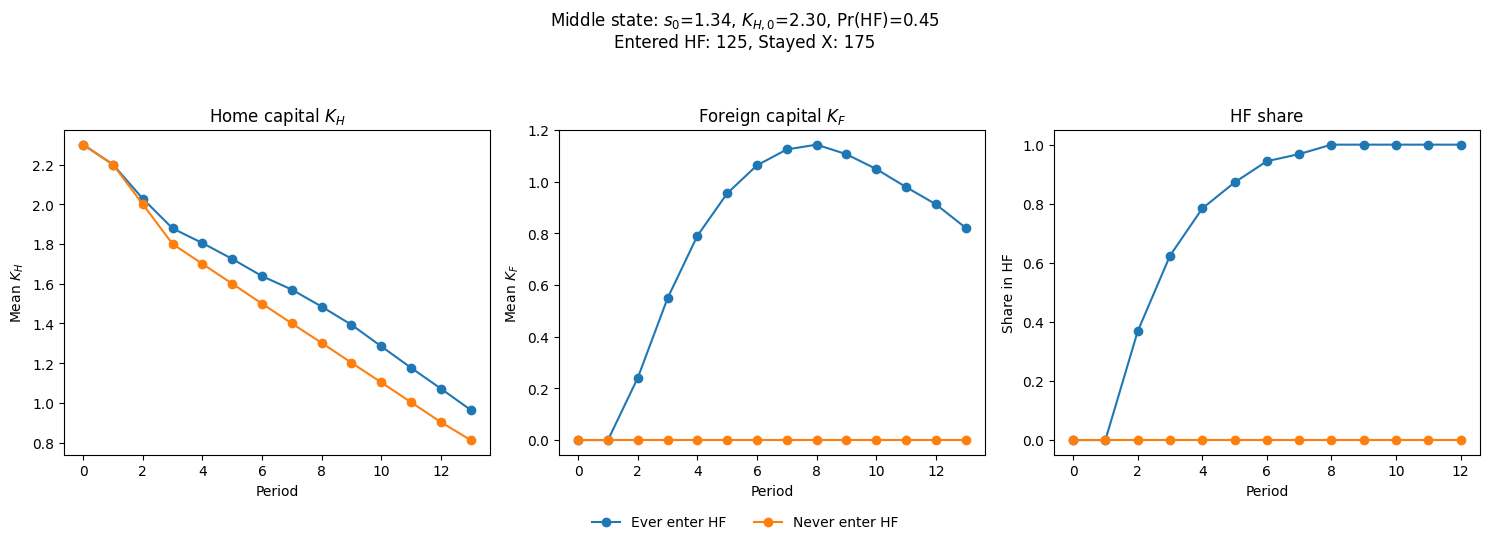

In [249]:
import numpy as np
import matplotlib.pyplot as plt

def plot_middle_state_divergence_1x3(
    sim_selected: dict,
    middle_label: str = "middle",
) -> None:
    """
    For the selected 'middle' state, split simulated firms into:
      - ever enter HF
      - never enter HF

    Then plot a 1x3 figure with average paths for:
      1. K_H
      2. K_F
      3. share in HF over time
    """
    if middle_label not in sim_selected:
        raise ValueError(f"Label '{middle_label}' not found in sim_selected.")

    paths = sim_selected[middle_label]["paths"]
    state_info = sim_selected[middle_label]["state_info"]

    entered_hf = [p for p in paths if any(m == "HF" for m in p["mode_path"])]
    stayed_x = [p for p in paths if all(m == "X" for m in p["mode_path"])]

    n_entered = len(entered_hf)
    n_stayed = len(stayed_x)

    if n_entered == 0:
        raise ValueError("No firms in the middle state enter HF.")
    if n_stayed == 0:
        raise ValueError("All firms in the middle state enter HF; no comparison group.")

    def mean_path(path_list, key):
        return np.array([p[key] for p in path_list], dtype=float).mean(axis=0)

    def hf_share_path(path_list):
        return np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in path_list
        ]).mean(axis=0)

    mean_KH_enter = mean_path(entered_hf, "KH_path")
    mean_KH_stay = mean_path(stayed_x, "KH_path")

    mean_KF_enter = mean_path(entered_hf, "KF_path")
    mean_KF_stay = mean_path(stayed_x, "KF_path")

    hf_share_enter = hf_share_path(entered_hf)
    hf_share_stay = hf_share_path(stayed_x)

    t_cap = np.arange(len(mean_KH_enter))
    t_mode = np.arange(len(hf_share_enter))

    title_text = (
        f"Middle state: $s_0$={state_info['s0']:.2f}, "
        f"$K_{{H,0}}$={state_info['KH0']:.2f}, "
        f"Pr(HF)={state_info['hf_share_ever']:.2f}\n"
        f"Entered HF: {n_entered}, Stayed X: {n_stayed}"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # Panel 1: K_H
    axes[0].plot(t_cap, mean_KH_enter, marker="o", label="Ever enter HF")
    axes[0].plot(t_cap, mean_KH_stay, marker="o", label="Never enter HF")
    axes[0].set_xlabel("Period")
    axes[0].set_ylabel(r"Mean $K_H$")
    axes[0].set_title(r"Home capital $K_H$")

    # Panel 2: K_F
    axes[1].plot(t_cap, mean_KF_enter, marker="o", label="Ever enter HF")
    axes[1].plot(t_cap, mean_KF_stay, marker="o", label="Never enter HF")
    axes[1].set_xlabel("Period")
    axes[1].set_ylabel(r"Mean $K_F$")
    axes[1].set_title(r"Foreign capital $K_F$")

    # Panel 3: Share in HF
    axes[2].plot(t_mode, hf_share_enter, marker="o", label="Ever enter HF")
    axes[2].plot(t_mode, hf_share_stay, marker="o", label="Never enter HF")
    axes[2].set_xlabel("Period")
    axes[2].set_ylabel("Share in HF")
    axes[2].set_title("HF share")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=min(3, len(labels)), frameon=False)
    fig.suptitle(title_text, y=1.05)
    plt.tight_layout()
    plt.show()


# Run:
plot_middle_state_divergence_1x3(sim_selected, middle_label="middle")

#### Condition on when firm enters HF

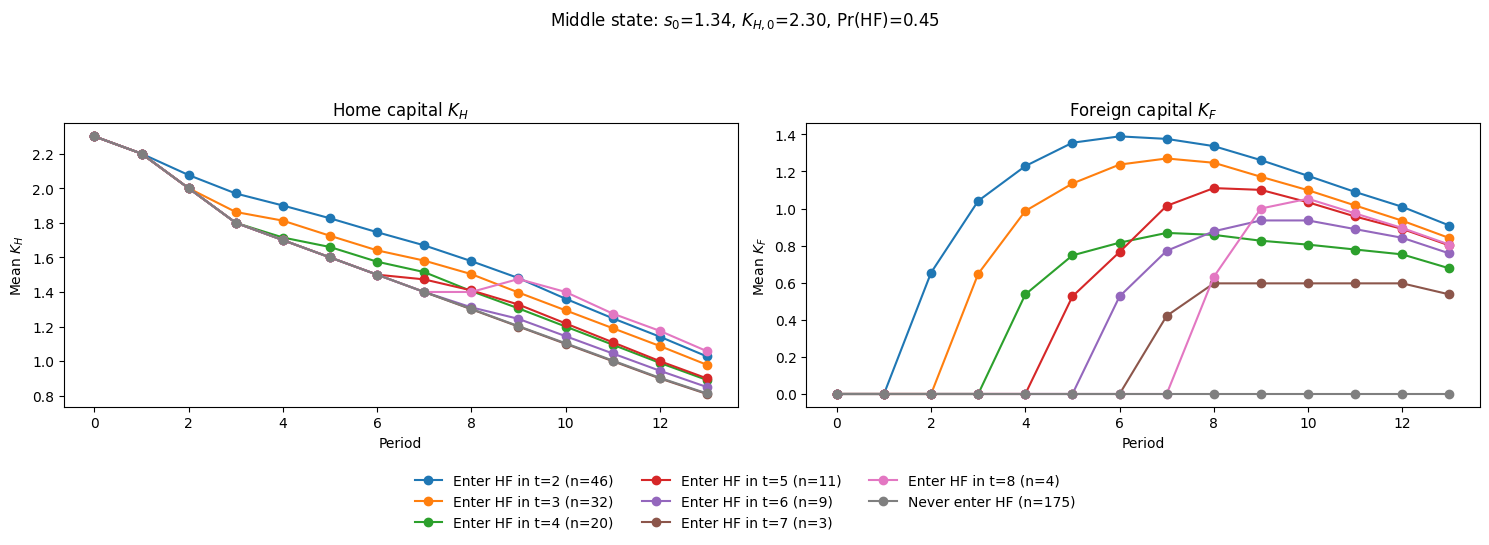

In [250]:
import numpy as np
import matplotlib.pyplot as plt

def plot_middle_state_by_entry_period_1x3(
    sim_selected: dict,
    middle_label: str = "middle",
    min_group_size: int = 1,
) -> None:
    """
    For the selected 'middle' state, group firms by the first period in which HF is entered.
    Adds one extra group for firms that never enter HF.

    Then plot a 1x3 figure with average paths for:
      1. K_H
      2. K_F
      3. share in HF over time

    Parameters
    ----------
    sim_selected : dict
        Output from simulate_selected_states(...)
    middle_label : str
        Key for the middle state in sim_selected
    min_group_size : int
        Only plot groups with at least this many firms
    """
    if middle_label not in sim_selected:
        raise ValueError(f"Label '{middle_label}' not found in sim_selected.")

    paths = sim_selected[middle_label]["paths"]
    state_info = sim_selected[middle_label]["state_info"]

    def first_hf_entry_period(mode_path):
        for t, m in enumerate(mode_path):
            if m == "HF":
                return t
        return None

    # ---------------------------------------
    # Build groups: t=0,1,2,... and "never"
    # ---------------------------------------
    groups = {}
    for p in paths:
        entry_t = first_hf_entry_period(p["mode_path"])
        key = "never" if entry_t is None else int(entry_t)
        groups.setdefault(key, []).append(p)

    # Keep only sufficiently large groups
    groups = {k: v for k, v in groups.items() if len(v) >= min_group_size}
    if len(groups) == 0:
        raise ValueError("No groups satisfy min_group_size.")

    # Sort groups: entry periods first, then never
    ordered_keys = sorted([k for k in groups.keys() if k != "never"])
    if "never" in groups:
        ordered_keys.append("never")

    def mean_path(path_list, key):
        return np.array([p[key] for p in path_list], dtype=float).mean(axis=0)

    def hf_share_path(path_list):
        return np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in path_list
        ]).mean(axis=0)

    # Use first group to get lengths
    first_group = groups[ordered_keys[0]]
    t_cap = np.arange(len(first_group[0]["KH_path"]))
    t_mode = np.arange(len(first_group[0]["mode_path"]))

    title_text = (
        f"Middle state: $s_0$={state_info['s0']:.2f}, "
        f"$K_{{H,0}}$={state_info['KH0']:.2f}, "
        f"Pr(HF)={state_info['hf_share_ever']:.2f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

    for key in ordered_keys:
        grp = groups[key]
        n_grp = len(grp)

        mean_KH = mean_path(grp, "KH_path")
        mean_KF = mean_path(grp, "KF_path")

        if key == "never":
            label = f"Never enter HF (n={n_grp})"
        else:
            label = f"Enter HF in t={key} (n={n_grp})"

        axes[0].plot(t_cap, mean_KH, marker="o", label=label)
        axes[1].plot(t_cap, mean_KF, marker="o", label=label)

    # Panel 1
    axes[0].set_xlabel("Period")
    axes[0].set_ylabel(r"Mean $K_H$")
    axes[0].set_title(r"Home capital $K_H$")

    # Panel 2
    axes[1].set_xlabel("Period")
    axes[1].set_ylabel(r"Mean $K_F$")
    axes[1].set_title(r"Foreign capital $K_F$")


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=min(3, len(labels)),
        frameon=False
    )
    fig.suptitle(title_text, y=1.03)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()


# Run:
plot_middle_state_by_entry_period_1x3(
    sim_selected,
    middle_label="middle",
    min_group_size=1,   # raise to 5 or 10 if you want to suppress tiny groups
)

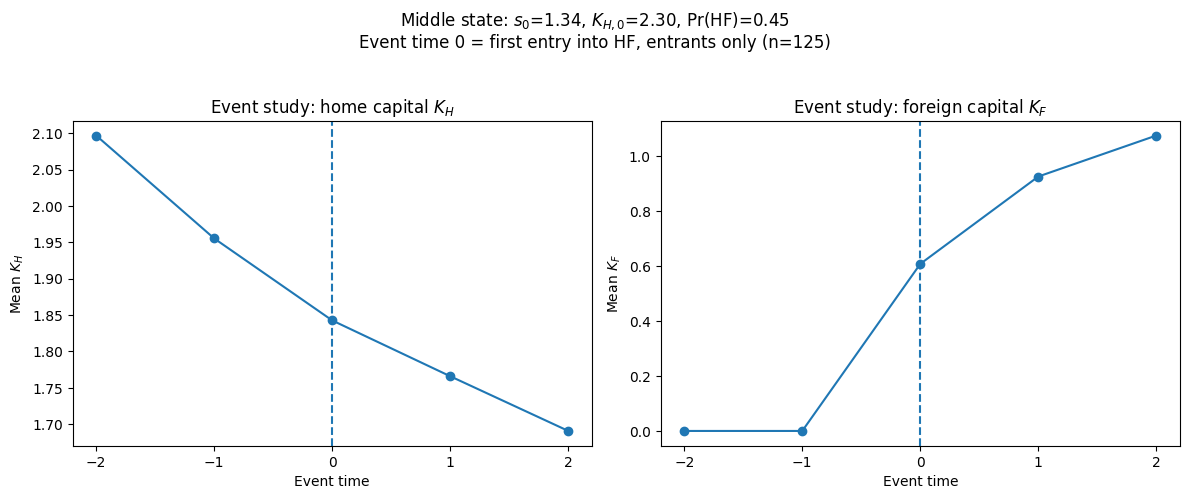

Number of observations contributing at each event time:
  t = -2: 125
  t = -1: 125
  t = +0: 125
  t = +1: 125
  t = +2: 125


In [251]:
import numpy as np
import matplotlib.pyplot as plt

def plot_middle_state_event_study(
    sim_selected: dict,
    middle_label: str = "middle",
    window_pre: int = 2,
    window_post: int = 2,
) -> None:
    """
    Event-study for the selected middle state.
    Uses only firms that ever enter HF and aligns paths by the first HF entry period.

    Plots mean K_H and mean K_F from event time -window_pre to +window_post,
    where event time 0 is first entry into HF.
    """
    if middle_label not in sim_selected:
        raise ValueError(f"Label '{middle_label}' not found in sim_selected.")

    paths = sim_selected[middle_label]["paths"]
    state_info = sim_selected[middle_label]["state_info"]

    def first_hf_entry_period(mode_path):
        for t, m in enumerate(mode_path):
            if m == "HF":
                return t
        return None

    event_times = np.arange(-window_pre, window_post + 1)

    kh_rows = []
    kf_rows = []

    for p in paths:
        entry_t = first_hf_entry_period(p["mode_path"])
        if entry_t is None:
            continue

        KH_path = p["KH_path"]   # length = n_periods + 1
        KF_path = p["KF_path"]

        kh_row = []
        kf_row = []

        for tau in event_times:
            t = entry_t + tau

            # Capital is indexed by period state, so valid indices are 0,...,n_periods
            if 0 <= t < len(KH_path):
                kh_row.append(KH_path[t])
                kf_row.append(KF_path[t])
            else:
                kh_row.append(np.nan)
                kf_row.append(np.nan)

        kh_rows.append(kh_row)
        kf_rows.append(kf_row)

    if len(kh_rows) == 0:
        raise ValueError("No firms in the selected state enter HF, so no event study can be computed.")

    KH_event = np.array(kh_rows, dtype=float)
    KF_event = np.array(kf_rows, dtype=float)

    mean_KH = np.nanmean(KH_event, axis=0)
    mean_KF = np.nanmean(KF_event, axis=0)

    n_by_tau = np.sum(~np.isnan(KH_event), axis=0)

    title_text = (
        f"Middle state: $s_0$={state_info['s0']:.2f}, "
        f"$K_{{H,0}}$={state_info['KH0']:.2f}, "
        f"Pr(HF)={state_info['hf_share_ever']:.2f}\n"
        f"Event time 0 = first entry into HF, entrants only (n={KH_event.shape[0]})"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    # Panel 1: K_H
    axes[0].plot(event_times, mean_KH, marker="o")
    axes[0].axvline(0, linestyle="--")
    axes[0].set_xlabel("Event time")
    axes[0].set_ylabel(r"Mean $K_H$")
    axes[0].set_title(r"Event study: home capital $K_H$")
    axes[0].set_xticks(event_times)

    # Panel 2: K_F
    axes[1].plot(event_times, mean_KF, marker="o")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_xlabel("Event time")
    axes[1].set_ylabel(r"Mean $K_F$")
    axes[1].set_title(r"Event study: foreign capital $K_F$")
    axes[1].set_xticks(event_times)

    fig.suptitle(title_text, y=1.03)
    plt.tight_layout()
    plt.show()

    # Optional: print support counts for each event time
    print("Number of observations contributing at each event time:")
    for tau, n in zip(event_times, n_by_tau):
        print(f"  t = {tau:+d}: {int(n)}")


# Run:
plot_middle_state_event_study(
    sim_selected,
    middle_label="middle",
    window_pre=2,
    window_post=2,
)

## Distrbutions in final period
1. Create a distribution of the productivity by state 
2. Create a distribution of the caqpital stock by state

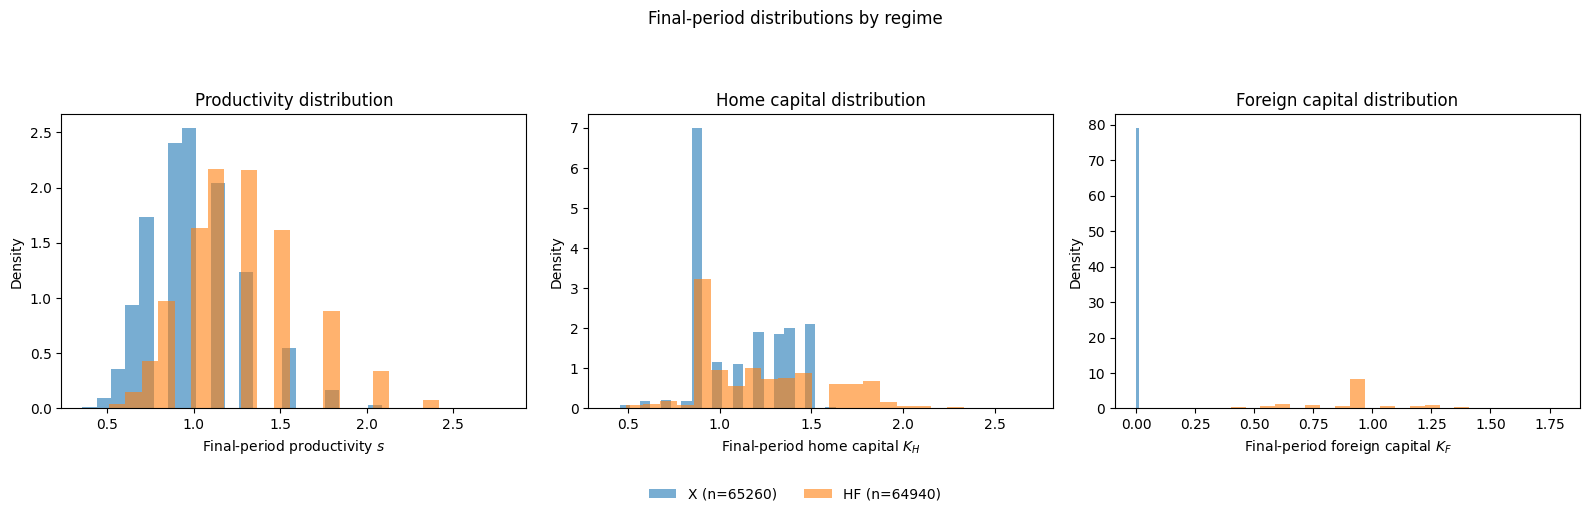

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_final_period_distribution_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    Build a DataFrame with the final operational-period state from the simulated paths.

    Final operational period means:
      - regime: mode_path[-1]
      - productivity: s_path[-1]
      - capital stocks used in that period: KH_path[-2], KF_path[-2]

    Returns one row per simulated firm-path.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            final_mode = path["mode_path"][-1]
            final_s = float(path["s_path"][-1])

            # Final operating-period capital stocks
            final_KH = float(path["KH_path"][-2])
            final_KF = float(path["KF_path"][-2])

            rows.append({
                "state_id": state["state_id"],
                "firm_id": firm_id,
                "s0": state["s0"],
                "KH0": state["KH0"],
                "KF0": state["KF0"],
                "final_mode": final_mode,
                "final_s": final_s,
                "final_KH": final_KH,
                "final_KF": final_KF,
            })

    return pd.DataFrame(rows)


def plot_final_period_distributions(final_df: pd.DataFrame, bins: int = 25) -> None:
    """
    Plot 1x3 histograms of final-period distributions by final regime:
      1. productivity s
      2. home capital K_H
      3. foreign capital K_F
    """
    df_X = final_df.loc[final_df["final_mode"] == "X"].copy()
    df_HF = final_df.loc[final_df["final_mode"] == "HF"].copy()

    if len(df_X) == 0:
        raise ValueError("No firms end in regime X.")
    if len(df_HF) == 0:
        raise ValueError("No firms end in regime HF.")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    # Panel 1: productivity
    axes[0].hist(df_X["final_s"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[0].hist(df_HF["final_s"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[0].set_xlabel(r"Final-period productivity $s$")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Productivity distribution")

    # Panel 2: home capital
    axes[1].hist(df_X["final_KH"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[1].hist(df_HF["final_KH"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[1].set_xlabel(r"Final-period home capital $K_H$")
    axes[1].set_ylabel("Density")
    axes[1].set_title(r"Home capital distribution")

    # Panel 3: foreign capital
    axes[2].hist(df_X["final_KF"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[2].hist(df_HF["final_KF"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[2].set_xlabel(r"Final-period foreign capital $K_F$")
    axes[2].set_ylabel("Density")
    axes[2].set_title(r"Foreign capital distribution")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)
    fig.suptitle("Final-period distributions by regime", y=1.02)
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()


# -----------------------------
# Run
# -----------------------------
final_df = build_final_period_distribution_df(sim_grid)
plot_final_period_distributions(final_df, bins=25)

# Simulate the HF states